In [28]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Reshape, Dropout
from keras.regularizers import l2
import numpy as np
import csv
import PIL
from IPython.display import Image

In [29]:
x = []
y = []

with open("data_new.csv", "r") as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=",")
    convert_rgb = lambda color: tuple(int(color[i:i+2], 16) for i in (0,2,4))
    for row in csv_reader:
        x.append(convert_rgb(row[0]))
        y.append([convert_rgb(x) for x in row[1].split(" ")])

train_x = np.array(x) / 255
train_y = np.array(y) / 255

train_x = np.reshape(train_x, (train_x.shape[0], 1, train_x.shape[1]))

In [30]:
# Define the model
model = Sequential()

# Add an LSTM layer as the encoder
model.add(LSTM(64, return_sequences=True, input_shape=(1, 3)))
model.add(Dropout(0.4))

# Add a dense layer to map the LSTM output to the desired output sequence length and dimensionality
model.add(Dense(3 * 3))

# Reshape the output to match the desired output sequence length and dimensionality
model.add(Reshape((3, 3)))

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Print the model summary
print(model.summary())

# Train the model
model.fit(train_x, train_y, epochs=10, batch_size=32, validation_split=0.2)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 1, 64)             17408     
                                                                 
 dropout_6 (Dropout)         (None, 1, 64)             0         
                                                                 
 dense_3 (Dense)             (None, 1, 9)              585       
                                                                 
 reshape_3 (Reshape)         (None, 3, 3)              0         
                                                                 
Total params: 17,993
Trainable params: 17,993
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/10


2024-05-28 17:17:53.974193: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-05-28 17:17:53.975353: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-05-28 17:17:53.976402: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

32/32 [==============================] - 2s 13ms/step - loss: 0.3941 - val_loss: 0.3074
Epoch 2/10
 1/32 [..............................] - ETA: 0s - loss: 0.3227

2024-05-28 17:17:55.797730: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-05-28 17:17:55.799089: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-05-28 17:17:55.800055: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

32/32 [==============================] - 0s 2ms/step - loss: 0.2439 - val_loss: 0.1652
Epoch 3/10
32/32 [==============================] - 0s 2ms/step - loss: 0.1444 - val_loss: 0.1171
Epoch 4/10
32/32 [==============================] - 0s 3ms/step - loss: 0.1235 - val_loss: 0.1092
Epoch 5/10
32/32 [==============================] - 0s 2ms/step - loss: 0.1173 - val_loss: 0.1034
Epoch 6/10
32/32 [==============================] - 0s 2ms/step - loss: 0.1120 - val_loss: 0.0979
Epoch 7/10
32/32 [==============================] - 0s 3ms/step - loss: 0.1061 - val_loss: 0.0929
Epoch 8/10
32/32 [==============================] - 0s 3ms/step - loss: 0.1005 - val_loss: 0.0883
Epoch 9/10
32/32 [==============================] - 0s 2ms/step - loss: 0.0953 - val_loss: 0.0838
Epoch 10/10
32/32 [==============================] - 0s 2ms/step - loss: 0.0904 - val_loss: 0.0799


In [35]:
# Prepare test input data (example)
test_color = [155, 0, 155]
test_input_color = np.array([test_color]) / 255  # Example RGB color, already normalized

# Reshape test input data to match model's input shape
test_input_color = np.reshape(test_input_color, (test_input_color.shape[0], 1, test_input_color.shape[1]))

# Predict output RGB colors
predicted_output_colors = model.predict(test_input_color)

# Optionally, denormalize predicted output colors if they were normalized during training
predicted_output_colors_denormalized = predicted_output_colors * 255.0

print("Test Input Color (Normalized):")
print(test_input_color)

print("Predicted Output Colors (DENormalized):")
print(predicted_output_colors_denormalized)


1/1 [==============================] - 0s 17ms/step
Test Input Color (Normalized):
[[[0.60784314 0.         0.60784314]]]
Predicted Output Colors (DENormalized):
[[[144.56525 129.93776 129.81798]
  [162.47849 139.55179 136.24994]
  [158.32393 154.58516 136.77058]]]


In [36]:
c1 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(test_color))
c2 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in predicted_output_colors_denormalized[0][0]))
c3 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in predicted_output_colors_denormalized[0][1]))
c4 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in predicted_output_colors_denormalized[0][2]))

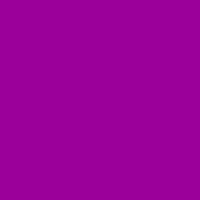

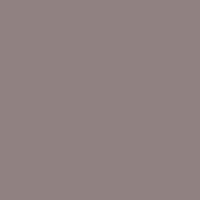

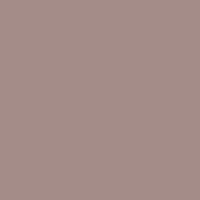

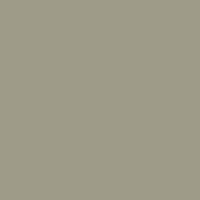

In [37]:
display(c1)
display(c2)
display(c3)
display(c4)